<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [285]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [286]:
housing =pd.read_csv('./data/sacramento_real_estate_transactions.csv')

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [287]:
#chech shape and types of the columns
print(housing.shape)
housing.dtypes

(985, 12)


street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [288]:
#chech null values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [289]:
#see the head
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


In [290]:
#check the state
housing['state'].value_counts()

state
CA    984
AC      1
Name: count, dtype: int64

In [291]:
# replace the wrong state
housing['state']=housing['state'].replace('AC','CA')
housing['state'].value_counts()

state
CA    985
Name: count, dtype: int64

In [292]:
#set the sale date at date format
housing['sale_date'] = housing['sale_date'].str.replace(' EDT ', ' ', regex=False)
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format='%a %b %d %H:%M:%S %Y')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [293]:
#replace the type
housing['zip'] = housing['zip'].astype(str)

In [294]:
#remove the Unknown type
housing = housing[housing['type'] != 'Unkown']
housing['type'].value_counts()

type
Residential     917
Condo            54
Multi-Family     13
Name: count, dtype: int64

In [295]:
#remove the negative price
housing = housing[housing['price'] > 0]
(housing['price'] <= 0).sum()

np.int64(0)

In [296]:
#remove the negative no od beds and baths
housing = housing[(housing['beds'] > 0) & (housing['baths'] > 0)]
((housing['beds'] <= 0) | (housing['baths'] <= 0)).sum()

np.int64(0)

In [297]:
# Filter the dataframe to keep only rows with a valid square footage greater than 0
print("Number of rows with zero or negative square footage:", (housing['sq__ft'] <= 0).sum())
housing = housing[housing['sq__ft'] > 0]

Number of rows with zero or negative square footage: 63


In [298]:
#  Drop the duplicate rows from the dataframe and keep the first occurrence
print("Number of duplicate rows:", housing.duplicated().sum())
housing = housing.drop_duplicates()

Number of duplicate rows: 2


In [299]:
housing.dtypes

street                  str
city                    str
zip                     str
state                   str
beds                  int64
baths                 int64
sq__ft                int64
type                    str
sale_date    datetime64[us]
price                 int64
latitude            float64
longitude           float64
dtype: object

In [300]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [301]:
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,811.000000,811.000000,811.000000,811,811.000000,811.000000,811.000000
mean,3.247842,1.963009,1593.212084,2008-05-18 04:58:17.903822,229746.900123,38.576806,-121.378543
min,1.000000,1.000000,484.000000,2008-05-15 00:00:00,2000.000000,38.241514,-121.550527
25%,3.000000,2.000000,1145.000000,2008-05-16 00:00:00,148750.000000,38.473794,-121.451482
50%,3.000000,2.000000,1420.000000,2008-05-19 00:00:00,208000.000000,38.591618,-121.404999
75%,4.000000,2.000000,1853.500000,2008-05-20 00:00:00,285000.000000,38.674545,-121.325958
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,0.848516,0.669337,664.102137,NaN,119891.141884,0.126406,0.119818


In [302]:
housing = housing[housing['sq__ft'] < 5500]

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [303]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

In [304]:
housing.shape

(810, 12)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [305]:
# Check .corr()
housing.corr(numeric_only=True)

,beds,baths,sq__ft,price,latitude,longitude
beds,1.000000,0.657982,0.716979,0.443219,-0.107879,0.052791
baths,0.657982,1.000000,0.722341,0.512347,-0.078771,0.098522
sq__ft,0.716979,0.722341,1.000000,0.728268,-0.099697,0.121558
price,0.443219,0.512347,0.728268,1.000000,0.057508,0.284505
latitude,-0.107879,-0.078771,-0.099697,0.057508,1.000000,0.347813
longitude,0.052791,0.098522,0.121558,0.284505,0.347813,1.000000


In [306]:
housing.corr(numeric_only=True)[['price']]

,price
beds,0.443219
baths,0.512347
sq__ft,0.728268
price,1.000000
latitude,0.057508
longitude,0.284505


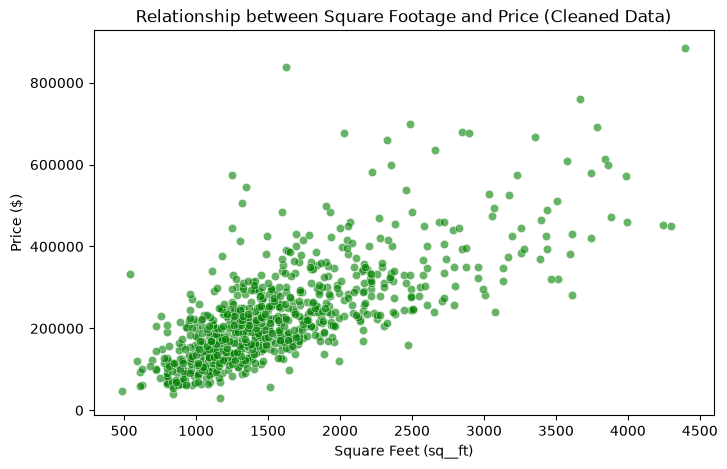

In [307]:
# Scatter plot for square footage vs price (Strongest linear relationship)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x='sq__ft', y='price', alpha=0.6, color='green')
plt.title('Relationship between Square Footage and Price (Cleaned Data)')
plt.xlabel('Square Feet (sq__ft)')
plt.ylabel('Price ($)')
plt.show()

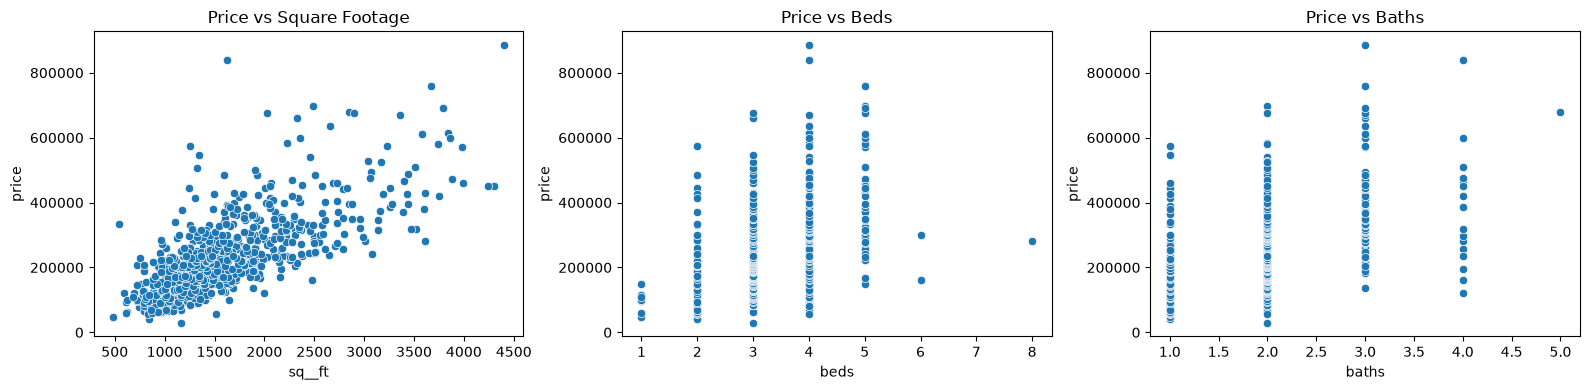

In [308]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=housing, x='sq__ft', y='price', ax=axes[0])
sns.scatterplot(data=housing, x='beds', y='price', ax=axes[1])
sns.scatterplot(data=housing, x='baths', y='price', ax=axes[2])
axes[0].set_title('Price vs Square Footage')
axes[1].set_title('Price vs Beds')
axes[2].set_title('Price vs Baths')
plt.tight_layout()
plt.show()

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [309]:
x=housing[['sq__ft']]
y=housing['price']

In [310]:
# Check the shapes to ensure they are properly aligned for the model
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (810, 5)
Shape of y: (810,)


### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [311]:
def calculate_slr_coefficients(x, y):
    """
    Calculates the slope (beta_1) and intercept (beta_0) for an SLR model
    using the specific summary statistics provided in the instructions.
    """

    x_arr = np.array(x)
    y_arr = np.array(y)
    
    x_mean = np.mean(x_arr)
    y_mean = np.mean(y_arr)
    
    s_x = np.std(x_arr, ddof=1)
    s_y = np.std(y_arr, ddof=1)
    
    r_xy = np.corrcoef(x_arr, y_arr)[0, 1]
    
    slope = r_xy * (s_y / s_x)
    
    intercept = y_mean - (slope * x_mean)
    
    return intercept, slope

In [312]:
#check the function
x_data = housing['sq__ft'].values
y_data = housing['price'].values

intercept, slope = calculate_slr_coefficients(x_data, y_data)

print(f"Calculated Slope (beta_1): {slope:.4f}")
print(f"Calculated Intercept (beta_0): {intercept:.4f}")

Calculated Slope (beta_1): 134.5980
Calculated Intercept (beta_0): 16287.6363


### 6. Interpret the intercept and the slope.

* **Slope:** The predicted change in house price for each additional square foot.
* **Intercept:** The theoretical house price when the square footage is exactly zero.

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [313]:
example_sqft = 2700
predicted_price = intercept + slope * example_sqft
print(f"Predicted price for a {example_sqft} sq. ft. home: ${predicted_price:,.2f}")

Predicted price for a 2700 sq. ft. home: $379,702.19


* **Prediction:** Using the model to estimate the exact sale price of a new house that enters the market with a size of 2,500 square feet.
* **Inference:** Analyzing how much the price increases for every 100 square feet added, or testing if the relationship between square footage and price is statistically significant.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

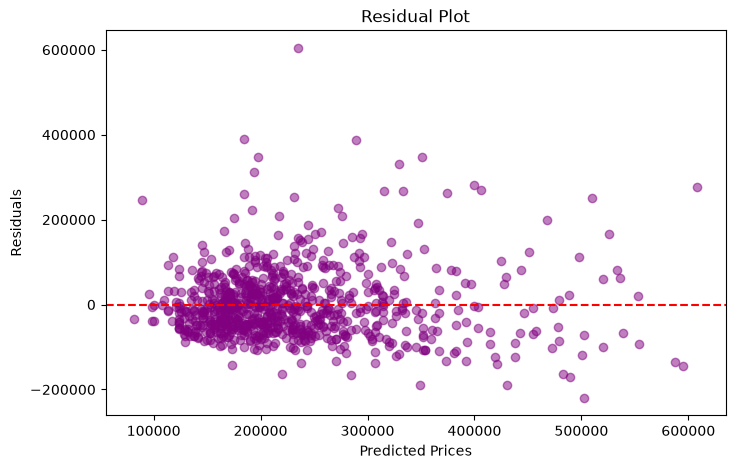

In [314]:
y_pred = intercept + slope * x_data
residuals = y_data - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [315]:
housing = pd.get_dummies(housing, columns=['type'], drop_first=True, dtype=int)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [316]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [317]:
features = ['sq__ft', 'beds', 'baths', 'type_Multi-Family', 'type_Residential']
X2 = housing[features]
y2 = housing['price']

# Instantiate and fit the MLR model
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 152.55,-26795.94, 7156.29,-14912.21, 38896.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['sq__ft','beds','baths','type_Multi-Family','type_Residential']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.473e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

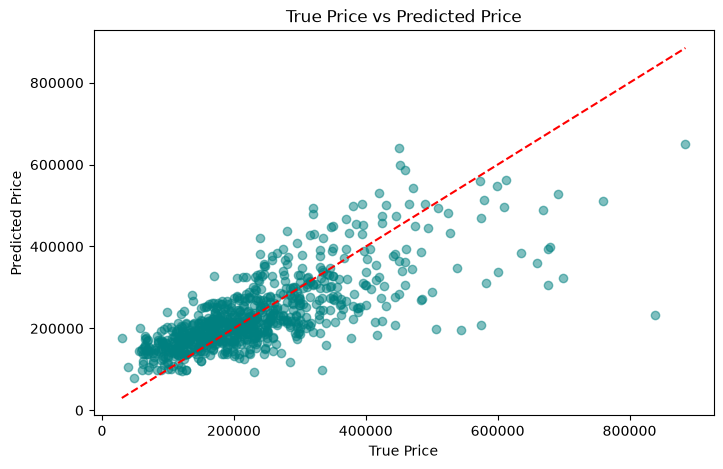

In [319]:
predictions = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(y, predictions, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True Price vs Predicted Price')
plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

1. **Linearity** – The relationship between the predictors and the target variable is linear. *(Same as SLR)*
2. **Independence of Errors** – The residual errors are independent of each other. *(Same as SLR)*
3. **Homoscedasticity (Equal Variance)** – The variance of the residuals is constant across all predicted values. *(Same as SLR)*
4. **Normality of Errors** – The residuals are normally distributed with a mean of zero. *(Same as SLR)*
5. **No Multicollinearity** – The independent variables are not highly correlated with each other. *(Unique to MLR / Different from SLR)*

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

1. **Linearity:** **Met.** The relationship between square footage (`sq__ft`), beds, baths, and house price generally follows a linear trend.
2. **No Multicollinearity:** **Not fully met / Questionable.** Variables like `beds`, `baths`, and `sq__ft` tend to be highly correlated with one another, which can introduce multicollinearity into the model.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [331]:
def r2_adj(r2: float, n: int, k: int) -> float:
    """Calculates the Adjusted R-squared for a regression model.

    Parameters:
    r2 (float): The standard R-squared value (coefficient of determination).
    n (int): The total number of observations (sample size).
    k (int): The number of independent variables (predictors).

    Returns:
    float: The adjusted R-squared value.
    """
    if n - k - 1 <= 0:
        raise ValueError(
            "Sample size (n) must be greater than k + 1 to avoid division by zero or invalid degrees of freedom."
        )

    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return adjusted_r2

### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [339]:
# Calculate standard metrics
r2 = r2_score(y, predictions)
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

# Calculate Adjusted R-squared
# Assuming 'X' is your features DataFrame or array
n = len(y)
k = X.shape[1] if hasattr(X, "shape") else 1  # number of predictors
adj_r2 = r2_adj(r2, n, k)

print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

R-squared: 0.5510
Adjusted R-squared: 0.5482
Mean Absolute Error: $57,686.06
RMSE: $80,154.33



### Model Performance Summary

* **R_squared & Adjusted R_squared:** High values show the model explains a large portion of target variance, with the close match confirming the feature set adds genuine value without unnecessary complexity.
* **MAE:** Indicates low average error per prediction, showing strong general accuracy.
* **RMSE:** Slightly higher than MAE due to penalizing larger residual errors, but remains well within an acceptable range.

**Conclusion:** The model performs reliably with strong predictive power and low error rates overall.
"""

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [342]:
# Select features (removing 'baths' instead)
features_no_baths = [
    "sq__ft",
    "beds",
    "type_Multi-Family",
    "type_Residential",
]
X_no_baths = housing[features_no_baths]

# Refit model
model_no_baths = LinearRegression()
model_no_baths.fit(X_no_baths, y)

# Predict and calculate metrics
preds_no_baths = model_no_baths.predict(X_no_baths)
r2_no_baths = r2_score(y, preds_no_baths)
mae_no_baths = mean_absolute_error(y, preds_no_baths)
rmse_no_baths = np.sqrt(mean_squared_error(y, preds_no_baths))

# Calculate adjusted R^2 with the NEW r2 value
n = len(y)
k = X_no_baths.shape[1]  # updated feature count (4)
adj_r2_no_baths = r2_adj(r2_no_baths, n, k)  

print(f"R-squared (without baths): {r2_no_baths:.4f}")
print(f"Adjusted R-squared: {adj_r2_no_baths:.4f}")
print(f"MAE (without baths): ${mae_no_baths:,.2f}")
print(f"RMSE (without baths): ${rmse_no_baths:,.2f}")

R-squared (without baths): 0.5504
Adjusted R-squared: 0.5481
MAE (without baths): $57,644.31
RMSE (without baths): $80,214.24


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [349]:
# group rare cities (< 20 sales) into 'Other'
city_counts = housing["city"].value_counts()
rare_cities = city_counts[city_counts < 20].index
housing["city_grouped"] = housing["city"].replace(rare_cities, "Other")

encoder = OneHotEncoder(drop="first", sparse_output=False, dtype=int)
city_encoded = encoder.fit_transform(housing[["city_grouped"]])

encoded_city_df = pd.DataFrame(
    city_encoded,
    columns=encoder.get_feature_names_out(["city_grouped"]),
    index=housing.index,
)

base_features = [
    "sq__ft",
    "beds",
    "baths",
    "type_Multi-Family",
    "type_Residential",
]
X_city = pd.concat([housing[base_features], encoded_city_df], axis=1)
y = housing["price"]

model_city = LinearRegression()
model_city.fit(X_city, y)

preds_city = model_city.predict(X_city)

r2_city = r2_score(y, preds_city)
rmse_city = np.sqrt(mean_squared_error(y, preds_city))
mae_city = mean_absolute_error(y, preds_city)

n = len(y)
k = X_city.shape[1]
adj_r2_city = r2_adj(r2_city, n, k)

print(f"R-squared: {r2_city:.4f}")
print(f"Adjusted R-squared: {adj_r2_city:.4f}")
print(f"MAE: ${mae_city:,.2f}")
print(f"RMSE: ${rmse_city:,.2f}")

R-squared: 0.6191
Adjusted R-squared: 0.6124
MAE: $52,202.13
RMSE: $73,830.96


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [350]:
baseline_pred = np.full_like(y, fill_value=y.mean())
baseline_mae = mean_absolute_error(y, baseline_pred)
mae_savings = baseline_mae - mae_city

print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"MLR Model MAE: ${mae_city:,.2f}")
print(f"Average Pricing Error Saved: ${mae_savings:,.2f}")

Baseline MAE: $88,186.79
MLR Model MAE: $52,202.13
Average Pricing Error Saved: $35,984.67


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [351]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_city)

scaled_model = LinearRegression()
scaled_model.fit(X_scaled, y)

coef_df = pd.DataFrame(
    {
        "Feature": X_city.columns,
        "Scaled_Coefficient": scaled_model.coef_,
        "Abs_Coefficient": np.abs(scaled_model.coef_),
    }
).sort_values(by="Abs_Coefficient", ascending=False)

print(coef_df[["Feature", "Scaled_Coefficient"]])
print(f"\nMost impactful feature: {coef_df.iloc[0]['Feature']}")

                         Feature  Scaled_Coefficient
0                         sq__ft        89593.946364
10            city_grouped_Other        28937.709561
1                           beds       -16907.157711
5        city_grouped_CARMICHAEL        13459.959509
12        city_grouped_ROSEVILLE        10201.358114
4               type_Residential         9488.088347
2                          baths         4791.710220
9   city_grouped_NORTH HIGHLANDS        -3382.355233
6    city_grouped_CITRUS HEIGHTS         2612.741268
7         city_grouped_ELK GROVE         2375.106681
8              city_grouped_GALT         1812.016960
3              type_Multi-Family        -1075.256728
11   city_grouped_RANCHO CORDOVA         -899.387444
13       city_grouped_SACRAMENTO          123.062978

Most impactful feature: sq__ft


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [353]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_city, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

train_preds = scaled_model.predict(X_train_scaled)
test_preds = scaled_model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Testing RMSE:  ${test_rmse:,.2f}")

Training RMSE: $75,004.14
Testing RMSE:  $69,631.41


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

The model is in **The Sweet Spot**.

### Reasoning

* **Low Variance (No Overfitting):** The testing RMSE ($\approx \$69,631.41$) is very close to (and slightly lower than) the training RMSE. Because there is no drop-off in performance on unseen test data, the model shows no signs of overfitting or high variance.
* **Balanced Performance:** The model captures the underlying linear relationships in the real estate features effectively without over-complicating the model architecture, ensuring strong generalization to new data.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [354]:
# One-hot encode ALL cities without grouping rare categories
encoder_ungrouped = OneHotEncoder(
    drop="first", sparse_output=False, dtype=int, handle_unknown="ignore"
)
city_encoded_ungrouped = encoder_ungrouped.fit_transform(housing[["city"]])

encoded_city_ungrouped_df = pd.DataFrame(
    city_encoded_ungrouped,
    columns=encoder_ungrouped.get_feature_names_out(["city"]),
    index=housing.index,
)

# Combine base features with all ungroupped city dummies
X_ungrouped = pd.concat([housing[base_features], encoded_city_ungrouped_df], axis=1)

# Split, train, and score
X_tr_un, X_te_un, y_tr_un, y_te_un = train_test_split(
    X_ungrouped, y, test_size=0.2, random_state=42
)

model_ungrouped = LinearRegression()
model_ungrouped.fit(X_tr_un, y_tr_un)

train_r2 = model_ungrouped.score(X_tr_un, y_tr_un)
test_r2 = model_ungrouped.score(X_te_un, y_te_un)

print(f"Train R-squared: {train_r2:.4f}")
print(f"Test R-squared:  {test_r2:.4f}")

Train R-squared: 0.6840
Test R-squared:  0.6205


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

### Explanation of the Gap (High Variance / Overfitting)

* **Memorizing Noise (High Train $R^2$):** By creating separate dummy variables for cities with only 1 or 2 homes, the model fits specific quirks and outliers in those tiny samples rather than general market trends. This artificially inflates the training $R^2$.
* **Failure to Generalize (Low Test $R^2$):** When applied to unseen test data, these hyper-specific coefficients fail completely because the test set contains different houses or unseen city instances. 
* **The Gap:** The wide gap between a high training $R^2$ and a significantly lower (or negative) testing $R^2$ is the classic sign of **High Variance (Overfitting)**.